Listing A1

In [1]:
import torch

tensor0d = torch.tensor(1)
print(tensor0d)

tensor1d = torch.tensor([1, 2, 3])
print(tensor1d)

tensor2d = torch.tensor([[1, 2, 3],[4,5,6]])
print(tensor2d)

tensor3d = torch.tensor([[[1, 2, 3],[4,5,6]],[[7,8.0,9],[10,11,12]]])
print(tensor3d)
print(tensor3d[1][1][2])

print(tensor3d.dtype)

tensor(1)
tensor([1, 2, 3])
tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[[ 1.,  2.,  3.],
         [ 4.,  5.,  6.]],

        [[ 7.,  8.,  9.],
         [10., 11., 12.]]])
tensor(12.)
torch.float32


In [2]:
print(tensor3d.shape)

tensor3d.view(2,2,3)

torch.Size([2, 2, 3])


tensor([[[ 1.,  2.,  3.],
         [ 4.,  5.,  6.]],

        [[ 7.,  8.,  9.],
         [10., 11., 12.]]])

In [3]:
tensor2d.T

tensor([[1, 4],
        [2, 5],
        [3, 6]])

In [4]:
print(tensor2d.matmul(tensor2d.T))

print(tensor2d @ tensor2d.T)

tensor([[14, 32],
        [32, 77]])
tensor([[14, 32],
        [32, 77]])


Listing A2

In [5]:
import torch.nn.functional as F

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2])
b = torch.tensor([0.0])

z = x1*w1+b 

a = torch.sigmoid(z)
loss = F.binary_cross_entropy(a,y)

print(z)
print(a)
print(loss)

tensor([2.4200])
tensor([0.9183])
tensor(0.0852)


Listing A3

In [6]:
import torch.nn.functional as А
from torch.autograd import grad

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = w1*x1+b
a = torch.sigmoid(z)
loss = F.binary_cross_entropy(a,y)
print(z,a,loss)

grad_L_w1 = grad(loss,w1,retain_graph=True)
grad_L_b = grad(loss,b, retain_graph=True)

print(grad_L_w1)
print(grad_L_b)
print()

loss.backward()
print(w1.grad)
print(b.grad)

tensor([2.4200], grad_fn=<AddBackward0>) tensor([0.9183], grad_fn=<SigmoidBackward0>) tensor(0.0852, grad_fn=<BinaryCrossEntropyBackward0>)
(tensor([-0.0898]),)
(tensor([-0.0817]),)

tensor([-0.0898])
tensor([-0.0817])


Listing A4

In [7]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()

        self.layers = torch.nn.Sequential(
            #first layer
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),

            #second layer
            torch.nn.Linear(30,20),
            torch.nn.ReLU(),

            #output layer
            torch.nn.Linear(20, num_outputs),
        )
    def forward(self,x):
        logits = self.layers(x)
        return logits

In [8]:
torch.manual_seed(123)
model = NeuralNetwork(50,3)

print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)


In [9]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Total number of trainable model parameters:', num_params)

print(model.layers[0].weight)
print(model.layers[0].weight.shape)
print(model.layers[0].bias)

Total number of trainable model parameters: 2213
Parameter containing:
tensor([[-0.0577,  0.0047, -0.0702,  ...,  0.0222,  0.1260,  0.0865],
        [ 0.0502,  0.0307,  0.0333,  ...,  0.0951,  0.1134, -0.0297],
        [ 0.1077, -0.1108,  0.0122,  ...,  0.0108, -0.1049, -0.1063],
        ...,
        [-0.0787,  0.1259,  0.0803,  ...,  0.1218,  0.1303, -0.1351],
        [ 0.1359,  0.0175, -0.0673,  ...,  0.0674,  0.0676,  0.1058],
        [ 0.0790,  0.1343, -0.0293,  ...,  0.0344, -0.0971, -0.0509]],
       requires_grad=True)
torch.Size([30, 50])
Parameter containing:
tensor([-0.1250,  0.0513,  0.0366,  0.0075,  0.0509,  0.0545, -0.0393,  0.0924,
        -0.1412, -0.1232, -0.1063,  0.0081, -0.1249,  0.0101, -0.0019, -0.1298,
         0.1388, -0.0330,  0.1017,  0.1247, -0.0554, -0.0417,  0.1388,  0.0159,
         0.1215,  0.0385,  0.0769, -0.1224, -0.0279,  0.0991],
       requires_grad=True)


In [10]:
torch.manual_seed(123)
X = torch.rand((1,50))
out = model(X)

print(out)

tensor([[-0.1262,  0.1080, -0.1792]], grad_fn=<AddmmBackward0>)


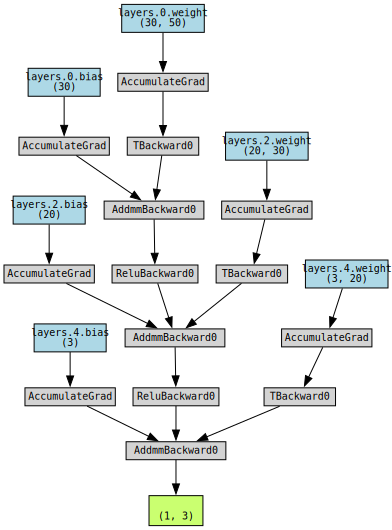

In [11]:
from torchviz import make_dot
make_dot(out, params=dict(model.named_parameters()))

In [12]:
with torch.no_grad():
    out = model(X)
print(out)

tensor([[-0.1262,  0.1080, -0.1792]])


In [13]:
with torch.no_grad():
    out = torch.softmax(model(X), dim=1)
print(out)

tensor([[0.3113, 0.3934, 0.2952]])


Listing А5. custom dataset

In [14]:
X_train = torch.tensor([
    [-1.2,3.1],
    [-0.9, 2.9],
    [-0.5,2.6],
    [2.3,-1.1],
    [2.7,-1.5]
])
y_train = torch.tensor([0,0,0,1,1])

X_test = torch.tensor([
    [-0.8,2.8],
    [2.6,-1.6]
])
y_test = torch.tensor([0,1])

Listing А6. Dataset

In [15]:
from torch.utils.data import Dataset

class ToyDataset(Dataset):
    def __init__(self,X,y):
        self.features = X
        self.labels = y
    
    def __getitem__(self,index):
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x,one_y
    
    def __len__(self):
        return self.labels.shape[0]

train_ds = ToyDataset(X_train, y_train)
test_ds = ToyDataset(X_test,y_test)

Listing А7. DataLoader

In [16]:
from torch.utils.data import DataLoader

torch.manual_seed(122)

train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

In [17]:
for idx, (x,y) in enumerate(train_loader):
    print(f"Batch {idx+1}:",x,y)

Batch 1: tensor([[-0.5000,  2.6000],
        [-1.2000,  3.1000]]) tensor([0, 0])
Batch 2: tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]) tensor([1, 0])


Listing А9. NN

In [18]:
import torch.nn.functional as F

torch.manual_seed(123)
model = NeuralNetwork(num_inputs=2,num_outputs=2)
optimizer = torch.optim.SGD(
    model.parameters(),lr=0.5
)

num_epochs=3
for epoch in range(num_epochs):
    model.train()

    for batch_idx, (features,labels) in enumerate(train_loader):
        logits = model(features)

        loss = F.cross_entropy(logits,labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### LOGGING
        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f"  |  Batch {batch_idx:03d}/{len(train_loader):03d}"
              f"  |  Train Loss: {loss:.2f}")
    model.eval()
    #optional eval code

Epoch: 001/003  |  Batch 000/002  |  Train Loss: 0.75
Epoch: 001/003  |  Batch 001/002  |  Train Loss: 0.65
Epoch: 002/003  |  Batch 000/002  |  Train Loss: 0.44
Epoch: 002/003  |  Batch 001/002  |  Train Loss: 0.13
Epoch: 003/003  |  Batch 000/002  |  Train Loss: 0.03
Epoch: 003/003  |  Batch 001/002  |  Train Loss: 0.00


In [19]:
model.eval()
with torch.no_grad():
    outputs = model(X_train)
print(outputs)

tensor([[ 2.8569, -4.1618],
        [ 2.5382, -3.7548],
        [ 2.0944, -3.1820],
        [-1.4814,  1.4816],
        [-1.7176,  1.7342]])


In [20]:
torch.set_printoptions(sci_mode=False)
probas = torch.softmax(outputs,dim=1)
print(probas)

tensor([[    0.9991,     0.0009],
        [    0.9982,     0.0018],
        [    0.9949,     0.0051],
        [    0.0491,     0.9509],
        [    0.0307,     0.9693]])


In [21]:
predictions = torch.argmax(probas, dim=1)
print(predictions)

tensor([0, 0, 0, 1, 1])


In [22]:
predictions = torch.argmax(outputs,dim=1)
print(predictions)

tensor([0, 0, 0, 1, 1])


In [23]:
display(predictions == y_train)
torch.sum(predictions==y_train)


tensor([True, True, True, True, True])

tensor(5)

Listing А10. compute_accuracy

In [24]:
def compute_accuracy(model, dataloader):
    model = model.eval()
    correct = 0
    total_examples = 0

    for idx, (features.labels) in dataloader:
        with torch.no_grad():
            logits = model(features)
        predictions = torch.argmax(logits, dim=1)
        compare = labels == predictions
        correct += torch.sum(compare)
        total_examples += len(compare)
    return (correct/total_examples).item()

display(compute_accuracy(model, train_loader))
compute_accuracy(model, test_loader)

1.0

1.0

Save model. Load model

In [25]:
torch.save(model.state_dict(),'model.pth')

model_new = NeuralNetwork(2,2)
model_new.load_state_dict(torch.load('model.pth'))

model_new(X_train)

tensor([[ 2.8569, -4.1618],
        [ 2.5382, -3.7548],
        [ 2.0944, -3.1820],
        [-1.4814,  1.4816],
        [-1.7176,  1.7342]], grad_fn=<AddmmBackward0>)

try cuda

In [26]:
print(torch.cuda.is_available())

torch.backends.mps.is_available()

False


True

In [27]:
tensor_1 = torch.tensor([1.,2.,3.])
tensor_2 = torch.tensor([4.,5.,6.])

print(tensor_1+tensor_2)

tensor([5., 7., 9.])


In [28]:
tensor_1 = torch.tensor([1.,2.,6.]).to('mps')
tensor_2 = torch.tensor([4.,5.,6.]).to('mps')

print(tensor_1+tensor_2)

tensor_1 = tensor_1.to("cpu")
print(tensor_1+tensor_2)# error

tensor([ 5.,  7., 12.], device='mps:0')


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, mps:0 and cpu!

In [ ]:
#make 2 matrices
import numpy as np

a = np.random.rand(5, 6)
b = np.random.rand(6,12)
print(a,b)

[[0.00875878 0.68535531 0.16341593 0.43443576 0.25118203 0.95980647]
 [0.93098326 0.85324279 0.95745199 0.9106129  0.22757615 0.45005071]
 [0.7703497  0.35470672 0.82705379 0.20827246 0.2806715  0.34773522]
 [0.99263256 0.5576463  0.65365981 0.86589154 0.05607187 0.99755943]
 [0.93586052 0.02873039 0.8656701  0.45449175 0.0147338  0.16724244]] [[0.57479278 0.06718651 0.1970694  0.76445802 0.94503236 0.89600881
  0.15528566 0.59185698 0.55782584 0.43223891 0.74287947 0.09610588]
 [0.89529267 0.60977923 0.92571454 0.39406924 0.3062328  0.71170832
  0.02368432 0.26704643 0.15985257 0.13794138 0.15535246 0.99453635]
 [0.5544611  0.66983969 0.31294661 0.91000111 0.34120891 0.13975634
  0.60331806 0.33015959 0.9688971  0.91724046 0.18338609 0.35052891]
 [0.7026181  0.45877321 0.21834298 0.78248238 0.59478124 0.21960372
  0.05500092 0.42563293 0.23136169 0.75762462 0.71897772 0.5517211 ]
 [0.89685879 0.21483764 0.22459209 0.51552284 0.4815992  0.16876357
  0.94410233 0.52460611 0.49867061 0.5

In [89]:
#make 2 matrices and check speed of their multiplication on CPU/MPS
import time

# CPU
a_cpu = torch.rand(5000, 5000)
b_cpu = torch.rand(5000, 5000)

torch.mps.synchronize()
start = time.time()
for _ in range(100):
    c = a_cpu @ b_cpu
print(f"CPU: {(time.time()-start)/100:.4f} sec")

# GPU
a_mps = torch.rand(5000, 5000, device='mps')
b_mps = torch.rand(5000, 5000, device='mps')

torch.mps.synchronize()
start = time.time()
for _ in range(100):
    c = a_mps @ b_mps
    torch.mps.synchronize()
print(f"MPS: {(time.time()-start)/100:.4f} sec")

CPU: 0.2276 sec
MPS: 0.1628 sec


Listing A13. Distribute learning

In [96]:
#for CUDA only
import torch.multiprocessing as mp
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group


def ddp_setup(rank,world_size):
    os.environ['MASTER_ADR'] = "localhost"
    os.environ["MASTER_PORT"] = "12345"
    init_process_group(
        backend="nccl",
        rank=rank,
        world_size=world_size
    )
    torch.cuda.set_device(rank)

def prepare_dataset():
    # input code with preparing of data
    train_loader = DataLoader(
        dataset=train_ds,
        batch_size=2,
        shuffle=False,
        pin_memory=True,
        drop_last=True,
        sampler=DistributedSampler(train_ds)
    )
    return train_loader, test_loader

def main(rank, world_size, num_epochs):
    ddp_setup(rank,world_size),
    train_loader, test_loader = prepare_dataset()
    model = NeuralNetwork(num_inputs=2, num_outputs=2) 
    model.to(rank)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
    model = DDP(model,device_ids=[rank])
    for epoch in range(num_epochs):
        for features, labels in train_loader:
            #input inference model and backpropagation
            print(f"GPU[rank] Epoch: {epoch+1:03d}/{num_epochs:03d}"
                  f" | Batchsize {labels.shape[0]:03d}"
                  f" | Train/Val Loss: {loss:02f}")
    model.eval()
    train_acc = compute_accuracy(model, train_loader, device=rank)
    print(f"[GPU{rank}] Training accuracy", train_acc)
    test_acc = compute_accuracy(model,test_loader, device=rank)
    print(f"[GPU{rank}] Test accuracy", test_acc)
    destroy_process_group()

if __name__ == "__main__":
    print("Number of GPUs available:", torch.cuda.device_count())
    torch.manual_seed(123)
    num_epochs=3
    world_size = torch.cuda.device_count()
    mp.spawn(main, args=(world_size, num_epochs), nprocs=world_size)



Number of GPUs available: 0
